# HW #4 - Wine Sales: Poisson / Negative Binomial

#### Northwestern MSDS - Supervised Machine Learning

**Goal**: improve on the HW03 model by predicting the actual **count** of cases sold (`TARGET`, from `wine_train.csv` / `wine_train_logistic.csv` - both share identical predictor data, confirmed by row-for-row comparison after joining on `INDEX`) using Poisson and/or Negative Binomial regression, rather than the binary sold/not-sold used in HW03. 

Data preparation (sign fix, `STARS_missing` flag, imputation, standardization) is reused unchanged from HW03, since those decisions are properties of the predictors, not the target. 

**Correction, per feedback**: the original HW04 submission fit a single Poisson regression to the full training population and rounded its predicted mean to get `P_TARGET`. Since every wine's predicted mean (`mu`) was above 0.5, zero test records were predicted as `P_TARGET = 0`, despite ~21.4% of real wines selling zero cases. 

--- 
### Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind, ks_2samp

import statsmodels.genmod.generalized_linear_model as glm_module
glm_module.SET_USE_BIC_LLF(True)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
# Loaded from wine_train_logistic.csv, which contains BOTH TARGET (count) and TARGET_1 (binary)
# using this file lets us reuse HW03's prep pipeline unchanged. 
train = pd.read_csv('wine_train_logistic.csv', encoding='utf-8-sig')
test = pd.read_csv('wine_test.csv', encoding='utf-8-sig')

print(train.shape, test.shape)
train.head()

(12795, 17) (3335, 16)


,INDEX,TARGET,TARGET_1,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
0,1,3,1,3.2,1.160,-0.98,54.2,-0.567,NaN,268.0,0.99280,3.33,-0.59,9.9,0,8,2.0
1,2,3,1,4.5,0.160,-0.81,26.1,-0.425,15.0,-327.0,1.02792,3.38,0.70,NaN,-1,7,3.0
2,4,5,1,7.1,2.640,-0.88,14.8,0.037,214.0,142.0,0.99518,3.12,0.48,22.0,-1,8,3.0
3,5,3,1,5.7,0.385,0.04,18.8,-0.425,22.0,115.0,0.99640,2.24,1.83,6.2,-1,6,1.0
4,6,4,1,8.0,0.330,-1.26,9.4,NaN,-167.0,108.0,0.99457,3.12,1.77,13.7,0,9,2.0


---
### Data Preparation (reused from HW03)

Sign fix (`abs()`), `STARS_missing` flag, median/mean imputation, and standardized quadratic terms. Identical pipeline to HW03, since these are properties of the predictor variables and don't depend on which target is being modeled. 

In [5]:
sign_cols = ['FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar', 
             'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide', 'Sulphates']

train_abs = train.copy()
train_abs[sign_cols] = train_abs[sign_cols].abs()

mcar_median_cols = ['Sulphates', 'TotalSulfurDioxide', 'FreeSulfurDioxide', 'Chlorides', 'ResidualSugar']
mcar_mean_cols = ['Alcohol', 'pH']
fill_values = {c: train_abs[c].median() for c in mcar_median_cols}
fill_values.update({c: train_abs[c].mean() for c in mcar_mean_cols})
fill_values['STARS'] = train_abs['STARS'].median()

def prepare_wine_data(df, sign_cols, fill_values):
    """HW03 Section 02 pipeline: sign fix -> STARS_missing flag -> impute (train-derived fill values)."""
    out = df.copy()
    out[sign_cols] = out[sign_cols].abs()
    out['STARS_missing'] = out['STARS'].isna().astype(int)
    for col, val in fill_values.items():
        out[col] = out[col].fillna(val)
    return out

train_prepped = prepare_wine_data(train, sign_cols, fill_values)
test_prepped = prepare_wine_data(test, sign_cols, fill_values)

std_cols = ['Sulphates', 'TotalSulfurDioxide', 'Chlorides', 'Density', 'FixedAcidity', 'FreeSulfurDioxide']
std_means = {col: train_prepped[col].mean() for col in std_cols}
std_stds = {col: train_prepped[col].std() for col in std_cols}

for df in [train_prepped, test_prepped]:
    for col in std_cols:
        df[f'{col}_std'] = (df[col] - std_means[col]) / std_stds[col]
        df[f'{col}_std_sq'] = df[f'{col}_std'] ** 2

print('Remaining missing values, train:')
print(train_prepped.isna().sum()[train_prepped.isna().sum() > 0])
print()
print('Remaining missing values, test (TARGET/TARGET_1 expected to be all-missing):')
print(test_prepped.isna().sum()[test_prepped.isna().sum() > 0])

Remaining missing values, train:
Series([], dtype: int64)

Remaining missing values, test (TARGET/TARGET_1 expected to be all-missing):
TARGET    3335
dtype: int64


---
### Exploring the Count Target (`TARGET`)

Checking the mean-variance relationship, since Poisson assumes variance = mean, while overdispersed data (variance > mean) points toward Negative Binomial. 

In [7]:
print('Mean of TARGET: ', train_prepped['TARGET'].mean())
print('Variance of TARGET: ', train_prepped['TARGET'].var())
print('Variance / Mean ratio: ', train_prepped['TARGET'].var() / train_prepped['TARGET'].mean())

Mean of TARGET:  3.0290738569753812
Variance of TARGET:  3.710894522839234
Variance / Mean ratio:  1.225092123222334


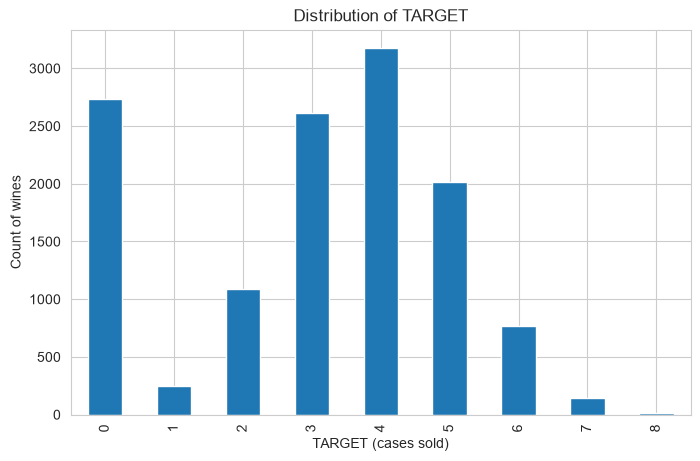

Pct of records with TARGET = 0: 21.36772176631497


In [8]:
plt.figure(figsize=(8, 5))
train_prepped['TARGET'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('TARGET (cases sold)')
plt.ylabel('Count of wines')
plt.title('Distribution of TARGET')
plt.show()

print('Pct of records with TARGET = 0:', (train_prepped['TARGET'] == 0).mean() * 100)

**Raw (unconditional) variance/mean ratio = 1.23**: variance exceeds the mean by about 23%, a mild signal of overdispersion under a naive Poisson assumption. This is only a first pass. However, it says nothing about whether the same overdispersion persists once predictor variables are accounted for (checking formally below, after fitting a model). Raw unconditional dispersion can partly reflect ordinary, explainable variation (e.g., higher `STARS` wines naturally selling more) rather than a true violation of the Poisson variance assumption. 

---
### Variable Selection - Poisson Stepwise (AIC and BIC)

Re-running variable selection from scratch rather than reusing HW03's logistic-selected variables, since the drivers of *whether* a wine sells (binary) may differ from the drivers of *how many* cases sell (count) (e.g., `LabelAppeal` was a weak predictor of `TARGET_1` in HW03 but a strong predictor of `TARGET` among wines that did sell). 

**Leakage check**: `TARGET_1` is excluded from the candidate pool, since `TARGET_1` is definitionally `TARGET > 0`. Including it would mean using a direct restatement of the target as a predictor. 

In [10]:
full_candidates = [
    'STARS', 'STARS_missing', 'AcidIndex', 'LabelAppeal',
    'VolatileAcidity', 'CitricAcid', 'Alcohol', 'pH', 'ResidualSugar',
    'Sulphates_std', 'Sulphates_std_sq',
    'TotalSulfurDioxide_std', 'TotalSulfurDioxide_std_sq',
    'Chlorides_std', 'Chlorides_std_sq',
    'Density_std', 'Density_std_sq',
    'FixedAcidity_std', 'FixedAcidity_std_sq',
    'FreeSulfurDioxide_std', 'FreeSulfurDioxide_std_sq',
]

y_count = train_prepped['TARGET']

def fit_poisson(vars_list, y, df):
    X = sm.add_constant(df[vars_list]) if vars_list else pd.DataFrame({'const': np.ones(len(df))}, index=df.index)
    return sm.GLM(y, X, family=sm.families.Poisson()).fit()

def stepwise_poisson(y, df, candidates, criterion='aic', verbose=True):
    """Bidirectional stepwise selection for Poisson regression, driven by AIC or BIC."""
    included = []
    def score(vars_list):
        m = fit_poisson(vars_list, y, df)
        return m.aic if criterion == 'aic' else m.bic

    current_score = score(included)
    improved = True
    while improved:
        improved = False
        excluded = [v for v in candidates if v not in included]
        best_add_score, best_add_var = current_score, None
        for v in excluded:
            trial = included + [v]
            try:
                s = score(trial)
            except Exception:
                continue
            if s < best_add_score:
                best_add_score, best_add_var = s, v
        if best_add_var is not None:
            included.append(best_add_var)
            current_score = best_add_score
            improved = True
            if verbose:
                print(f'+ add {best_add_var:30s} {criterion.upper()}={current_score:.2f}')

        best_drop_score, best_drop_var = current_score, None
        for v in included:
            trial = [x for x in included if x != v]
            try:
                s = score(trial)
            except Exception:
                continue
            if s < best_drop_score:
                best_drop_score, best_drop_var = s, v
        if best_drop_var is not None:
            included.remove(best_drop_var)
            current_score = best_drop_score
            improved = True
            if verbose:
                print(f'- drop {best_drop_var:30s} {criterion.upper()}={current_score:.2f}')

    return included, current_score

print('=== Poisson stepwise: AIC ===')
poisson_aic_vars, poisson_aic_score = stepwise_poisson(y_count, train_prepped, full_candidates, criterion='aic')
print('\nFinal AIC-selected variables:', poisson_aic_vars)

print('\n=== Poisson stepwise: BIC ===')
poisson_bic_vars, poisson_bic_score = stepwise_poisson(y_count, train_prepped, full_candidates, criterion='bic')
print('\nFinal BIC-selected variables:', poisson_bic_vars)

=== Poisson stepwise: AIC ===
+ add STARS_missing                  AIC=48625.02
+ add STARS                          AIC=46758.03
+ add LabelAppeal                    AIC=46134.46
+ add AcidIndex                      AIC=45783.77
+ add VolatileAcidity                AIC=45767.31
+ add TotalSulfurDioxide_std         AIC=45762.77
+ add Alcohol                        AIC=45758.34
+ add TotalSulfurDioxide_std_sq      AIC=45755.60
+ add pH                             AIC=45754.74
+ add Density_std                    AIC=45754.41
+ add Sulphates_std                  AIC=45754.23

Final AIC-selected variables: ['STARS_missing', 'STARS', 'LabelAppeal', 'AcidIndex', 'VolatileAcidity', 'TotalSulfurDioxide_std', 'Alcohol', 'TotalSulfurDioxide_std_sq', 'pH', 'Density_std', 'Sulphates_std']

=== Poisson stepwise: BIC ===
+ add STARS_missing                  BIC=48639.94
+ add STARS                          BIC=46780.40
+ add LabelAppeal                    BIC=46164.29
+ add AcidIndex               

**Result**: both criteria agree on the same first 5 variables (`STARS_missing`, `STARS`, `LabelAppeal`, `AcidIndex`, `VolatileAcidity`) before AIC continues adding 6 more (`TotalSulfurDioxide_std`, `Alcohol`, `TotalSulfurDioxide_std_sq`, `pH`, `Density_std`, `Sulphates_std`). BIC stops at the 5-variable set. The overlap is a strong, convergent signal these 5 are genuinely important. 

---
### Fit Poisson Model (BIC-selected variables) and Check Conditional Dispersion

In [19]:
bic_vars = ['STARS_missing', 'STARS', 'LabelAppeal', 'AcidIndex', 'VolatileAcidity']

X_poisson_bic = sm.add_constant(train_prepped[bic_vars])
poisson_bic = sm.GLM(y_count, X_poisson_bic, family=sm.families.Poisson()).fit()
print(poisson_bic.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 TARGET   No. Observations:                12795
Model:                            GLM   Df Residuals:                    12789
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -22878.
Date:                Mon, 17 Aug 2026   Deviance:                       13813.
Time:                        20:45:21   Pearson chi2:                 1.13e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5069
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.5233      0.038     

In [21]:
print('Deviance:', poisson_bic.deviance)
print('Pearson chi2:', poisson_bic.pearson_chi2)
print('DF residuals:', poisson_bic.df_resid)
print('Deviance / DF:', poisson_bic.deviance / poisson_bic.df_resid)
print('Pearson chi2 / DF:', poisson_bic.pearson_chi2 / poisson_bic.df_resid)

Deviance: 13813.28354655778
Pearson chi2: 11340.455317517048
DF residuals: 12789
Deviance / DF: 1.0800909802609884
Pearson chi2 / DF: 0.8867351096658884


**Result**: Deviance/DF = 1.08 (mild overdispersion signal), Pearson chi2/DF = 0.89 (mild underdispersion signal). The two diagnostics disagree, and both are much closer to 1.0 than the raw, unconditional variance/mean ratio of 1.23. This suggests a meaningful share of what looked like overdispersion in the raw target was ordinary, explainable variation (e.g. `STARS` differences) that the model has now accounted for. The conditional (post-model) dispersion is what actually matters for judging whether Poisson's assumptions are violated, not the raw unconditional ratio. 

#### Cameron-Trivedi overdispersion test

A more formal test: regress the scaled squared residuals against the fitted values. A significant positive coefficient on the fitted value is direct evidence of overdispersion even after controlling for predictors. 

In [24]:
mu = poisson_bic.fittedvalues
resid = y_count - mu
aux_y = (resid**2 - y_count) / mu
aux_X = sm.add_constant(mu)

aux_model = sm.OLS(aux_y, aux_X).fit()
print(aux_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     3326.
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:50:19   Log-Likelihood:                -21682.
No. Observations:               12795   AIC:                         4.337e+04
Df Residuals:                   12793   BIC:                         4.338e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3132      0.027     48.127      0.0

**Result**: the coefficient on `mu` is -0.4698 (t = -57.671, p < 0.001). This is significant but in the wrong direction for Negative Binomial to help. NB is specifically designed to address overdispersion (variance growing faster than the mean); it has no mechanism for underdispersion (variance growing slower than the mean, which is what this significant negative coefficient indicates). Combined with Deviance/DF (1.08) and Pearson chi2/DF (0.89) both sitting close to 1 with no consistent direction, and the raw unconditional variance/mean ratio (1.23) being largely explained away one predictors are included, there is no compelling evidence of true overdispersion once the model accounts for `STARS`, `STARS_missing`, `LabelAppeal`, `AcidIndex`, and `VolatileAcidity`.

--- 
### Negative Binomial Model (fit anyway, for a direct comparison)

Even though the dignostics point toward Poisson being adequate, a Negative Binomial model is fit on the same 5 variables for a direct, like-for-like comparison. This isolates exactly what NB's extra dispersion parameter (alpha) buys over Poisson, rather than confounding the comparison with a different variable set. 

In [29]:
import statsmodels.discrete.discrete_model as dm

nb_bic = dm.NegativeBinomial(y_count, X_poisson_bic).fit(disp=0)
print(nb_bic.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                 TARGET   No. Observations:                12795
Model:               NegativeBinomial   Df Residuals:                    12789
Method:                           MLE   Df Model:                            5
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                  0.1578
Time:                        21:09:56   Log-Likelihood:                -22878.
converged:                      False   LL-Null:                       -27165.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.5236      0.038     40.030      0.000       1.449       1.598
STARS_missing      -1.0288      0.017    -60.648      0.000      -1.062      -0.996
STARS               0.1894      

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Result**: `alpha` is essentially zero (8.78e-08) and completely non-significant (p = 0.990). Negative Binomial is mathematically defined so that as alpha -> 0, it collapses exactly into the Poisson distribution. The MLE optimizer found no meaningful overdispersion to model and pushed the extra parameter to (numerically) nothing. Log-likelihoods are virtually identical between the two models, while AIC and BIC are both slightly worse for NB, since it pays a complexity penalty for an extra parameter that bought no improvement in fit. 

**Conclusion: Poisson is the better choice**, both theoretically (no evidence of true overdispersion) and empirically (better AIC/BIC, near-identical likelihood, statistically insignificant dispersion parameter). The final model uses the 5-variable BIC-selected POisson regression. 

--- 
### Converting Predictions to Integer Counts

Poisson regression's `.predict()` returns a continuous estimated mean, but `P_TARGET` must be a whole-number case count. Comparing rounding strategies against the real training-set counts. 

In [32]:
mu_pred = poisson_bic.fittedvalues

round_pred = np.round(mu_pred)
floor_pred = np.floor(mu_pred)

mae_round = np.abs(y_count - round_pred).mean()
mae_floor = np.abs(y_count - floor_pred).mean()

print('MAE (round):', mae_round)
print('MAE (floor):', mae_floor)

MAE (round): 1.0032043767096521
MAE (floor): 1.0905041031652989


**Result**: rounding to the nearest integer (MAE = 1.003) clearly beats truncating/fooring (MAE = 1.091). Flooring systemically discards the fractional part of ever prediction, biasing every estimate downward. Rounding treats over- and under-estimation symmetrically. Poisson's `exp()` link function guarantees `mu` is always positive, so rounding can never produce a negative `P_TARGET`

--- 
### Final Model Summary and Formula

**Selected model**: Poisson regression (BIC-selected, 5 variables): `STARS_missing`, `STARS`, `LabelAppeal`, `AcidIndex`, `VolatileAcidity`. 

**Formula:**
```
log(mu) =  const
           + coef_STARS_missing * STARS_missing
           + coef_STARS * STARS
           + coef_LabelAppeal * LabelAppeal
           + coef_AcidIndex * AcidIndex
           + coef_VolatileAcidity * VolatileAcidity

mu = exp(log(mu))
P_TARGET = round(mu)
```

Sign-fix and missing-value handling for `STARS`/`STARS_missing`/`VolatileAcidity` are identical to the HW03 pipeline. No additional transforms needed for this specific 5-variable set, since none of these are among the standardized-quadratic variables. 

In [35]:
coefs = poisson_bic.params
print('Fitted coefficients:')
for name, val in coefs.items():
    print(f' {name}: {val:.6f}')

Fitted coefficients:
 const: 1.523340
 STARS_missing: -1.028699
 STARS: 0.189470
 LabelAppeal: 0.158500
 AcidIndex: -0.082063
 VolatileAcidity: -0.040086


--- 
### Score Test Data

Applying the fitted Poisson model to `wine_test.csv` (already prepared via `test_prepped` using the same pipeline as `train_prepped`), producing the required two-column output. 

In [38]:
X_test_final = sm.add_constant(test_prepped[bic_vars], has_constant='add')

mu_test = poisson_bic.predict(X_test_final)
p_target_test = np.round(mu_test).astype(int)

scored = pd.DataFrame({
    'INDEX': test_prepped['INDEX'],
    'P_TARGET': p_target_test
})

print(scored.shape)
scored.head(10)

(3335, 2)


,INDEX,P_TARGET
0,3,1
1,9,4
2,10,3
3,18,2
4,21,1
5,30,6
6,31,3
7,37,2
8,39,1
9,47,1


#### Sanity checks

In [41]:
print('Missing INDEX values:', scored['INDEX'].isna().sum())
print('Missing P_TARGET values:', scored['P_TARGET'].isna().sum())
print('Row count matches wine_test.csv:', len(scored) == len(test_prepped))
print('Any negative P_TARGET values:', (scored['P_TARGET'] < 0).any())
print()
print('P_TARGET distribution:')
print(scored['P_TARGET'].value_counts().sort_index())
print()
print('Mean predicted P_TARGET:', scored['P_TARGET'].mean(),
      ' (training actual mean TARGET:', y_count.mean(), ')')

Missing INDEX values: 0
Missing P_TARGET values: 0
Row count matches wine_test.csv: True
Any negative P_TARGET values: False

P_TARGET distribution:
P_TARGET
1     761
2     322
3    1029
4     705
5     355
6     127
7      31
8       4
9       1
Name: count, dtype: int64

Mean predicted P_TARGET: 3.030584707646177  (training actual mean TARGET: 3.0290738569753812 )


**Result**: no missing or negative values, row count matches `wine_test.csv`, and the mean predicted count (~3.0) closely tracks the training set's actual mean (3.03)

#### Export final scored file

In [44]:
scored.to_csv('scottkeighley_410_hw04.csv', index=False)
print('Saved scottkeighley_410_hw04.csv')
scored.head()

Saved scottkeighley_410_hw04.csv


,INDEX,P_TARGET
0,3,1
1,9,4
2,10,3
3,18,2
4,21,1
